# Finite Difference Pricing with the Crank-Nicolson Method

This notebook investigates the numerical solution of the Black-Scholes partial differential equation using the Crank-Nicolson finite-difference method.

The main objectives are to:

- solve the Black-Scholes PDE numerically for European options;
- compare the Crank-Nicolson solution with the Black-Scholes analytical benchmark;
- investigate numerical convergence under grid refinement;
- compare analytical, Monte Carlo, and PDE-based pricing methods in terms of price accuracy and computational cost.

The analysis focuses not only on obtaining option prices, but also on evaluating the numerical properties of different computational finance methods.

In [1]:
import sys
from pathlib import Path
from time import perf_counter

cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

sys.path.insert(0, str(project_root))

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)

print("Project root:", project_root)

Project root: /Users/amber/derivatives-pricing-calibration


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models.black_scholes import (
    call_price,
)

from src.pricing.finite_difference import (
    crank_nicolson_price,
)

from src.pricing.monte_carlo import (
    monte_carlo_price,
)

## 1. Black-Scholes PDE and Finite-Difference Framework

The Black-Scholes model can be expressed as the following partial differential equation:

$$
\frac{\partial V}{\partial t}
+
\frac{1}{2}\sigma^2S^2
\frac{\partial^2 V}{\partial S^2}
+
rS\frac{\partial V}{\partial S}
-
rV
=
0
$$

where $V(S,t)$ denotes the value of the option.

For a European call option, the terminal condition is

$$
V(S,T)
=
\max(S-K,0).
$$

Instead of solving the PDE analytically, the finite-difference approach discretizes both the stock-price dimension and the time dimension.

The stock-price grid is defined by

$$
S_i
=
i\Delta S,
$$

while the time grid is defined by

$$
\tau_n
=
n\Delta \tau.
$$

The numerical solution therefore approximates the continuous option-pricing function $V(S,t)$ on a finite grid.

In [3]:
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.20

M = 400
N = 400

In [4]:
bs_price = call_price(
    S0,
    K,
    T,
    r,
    sigma,
)

print("Black-Scholes Price:", bs_price)

Black-Scholes Price: 10.450583572185565


## 2. Crank-Nicolson vs Black-Scholes Analytical Solution

The Crank-Nicolson method combines information from two adjacent time layers.

Its general discretized form can be expressed as

$$
\left(
I-\frac{\Delta\tau}{2}L
\right)V^{n+1}
=
\left(
I+\frac{\Delta\tau}{2}L
\right)V^n,
$$

where $L$ represents the spatial Black-Scholes differential operator.

The objective of this experiment is to determine whether the numerical PDE solution reproduces the Black-Scholes analytical benchmark.

For sufficiently fine stock-price and time grids, we expect

$$
V_{\mathrm{CN}}
\approx
V_{\mathrm{BS}}.
$$

In [5]:
cn_price, S_grid, cn_values = crank_nicolson_price(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_type="call",
    M=M,
    N=N,
    return_grid=True,
)

print("Black-Scholes Price:", bs_price)
print("Crank-Nicolson Price:", cn_price)
print("Absolute Error:", abs(cn_price - bs_price))

Black-Scholes Price: 10.450583572185565
Crank-Nicolson Price: 10.448113962350739
Absolute Error: 0.0024696098348258033


In [6]:
bs_values = np.zeros_like(S_grid)

bs_values[1:] = [
    call_price(
        S,
        K,
        T,
        r,
        sigma,
    )
    for S in S_grid[1:]
]

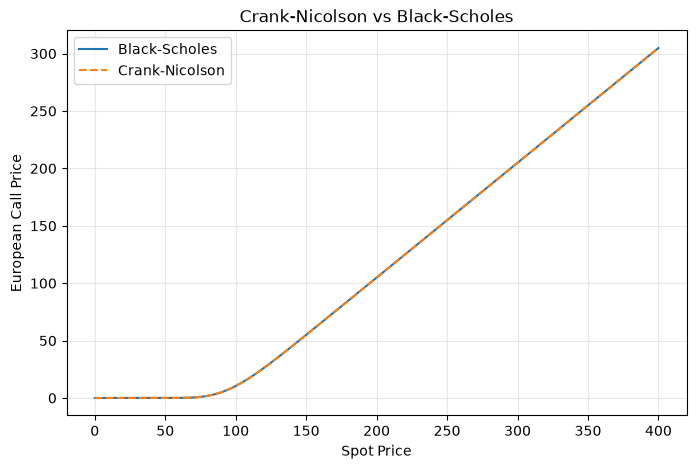

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    S_grid,
    bs_values,
    label="Black-Scholes",
)

plt.plot(
    S_grid,
    cn_values,
    linestyle="--",
    label="Crank-Nicolson",
)

plt.xlabel("Spot Price")
plt.ylabel("European Call Price")

plt.title(
    "Crank-Nicolson vs Black-Scholes"
)

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "cn_vs_black_scholes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 3. Grid Refinement and Numerical Convergence

A consistent numerical PDE solver should approach the analytical solution as the grid becomes finer.

Ideally,

$$
\Delta S,\Delta\tau
\rightarrow
0
\quad\Longrightarrow\quad
V_{\mathrm{CN}}
\rightarrow
V_{\mathrm{BS}}.
$$

For sufficiently smooth solutions, the classical Crank-Nicolson scheme combined with central spatial differences has a theoretical discretization error of approximately

$$
\text{Error}
=
O\left(
(\Delta S)^2
+
(\Delta\tau)^2
\right).
$$

In practice, the European option payoff contains a kink at the strike price at maturity, so empirical convergence may not be perfectly monotonic for every grid configuration.

This experiment evaluates both numerical error and computational time as the grid is refined.

In [8]:
grid_sizes = [
    50,
    100,
    200,
    400,
    800,
]

cn_prices = []
cn_errors = []
cn_runtimes = []

for grid_size in grid_sizes:

    start = perf_counter()

    price = crank_nicolson_price(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        option_type="call",
        M=grid_size,
        N=grid_size,
    )

    end = perf_counter()

    error = abs(
        price - bs_price
    )

    runtime = end - start

    cn_prices.append(price)
    cn_errors.append(error)
    cn_runtimes.append(runtime)

In [9]:
convergence_results = pd.DataFrame({
    "Grid Size": grid_sizes,
    "CN Price": cn_prices,
    "Absolute Error": cn_errors,
    "Runtime (seconds)": cn_runtimes,
})

convergence_results

,Grid Size,CN Price,Absolute Error,Runtime (seconds)
0,50,10.594607,0.144024,0.001156
1,100,10.410792,0.039791,0.001056
2,200,10.440692,0.009892,0.002905
3,400,10.448114,0.002470,0.006682
4,800,10.449966,0.000617,0.014120


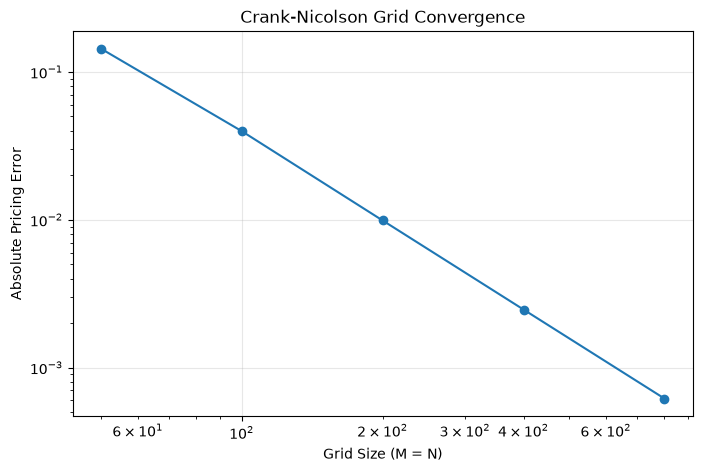

In [10]:
plt.figure(figsize=(8, 5))

plt.loglog(
    grid_sizes,
    cn_errors,
    marker="o",
)

plt.xlabel("Grid Size (M = N)")
plt.ylabel("Absolute Pricing Error")

plt.title(
    "Crank-Nicolson Grid Convergence"
)

plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "cn_convergence.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [11]:
empirical_orders = []

for i in range(len(cn_errors) - 1):
    p = np.log(
        cn_errors[i] / cn_errors[i + 1]
    ) / np.log(2)

    empirical_orders.append(p)

for i, p in enumerate(empirical_orders):
    print(
        f"{grid_sizes[i]} -> {grid_sizes[i+1]}: "
        f"empirical order = {p:.3f}"
    )

50 -> 100: empirical order = 1.856
100 -> 200: empirical order = 2.008
200 -> 400: empirical order = 2.002
400 -> 800: empirical order = 2.000


### Empirical Convergence Order

The numerical convergence order can be estimated using

$$
p
=
\frac{
\log(E_h/E_{h/2})
}{
\log 2
},
$$

where $E_h$ denotes the pricing error associated with grid spacing $h$.

An empirical value close to

$$
p \approx 2
$$

is consistent with second-order convergence.

The results indicate that the Crank-Nicolson implementation exhibits approximately second-order convergence under the grid-refinement configuration considered here.
The convergence order approaches 2 as the grid is refined, suggesting that the numerical scheme has entered its asymptotic second-order convergence regime for sufficiently fine grids.

## 4. Cross-Method Comparison

Three different approaches to European option pricing are now available:

**Black-Scholes analytical pricing**

A closed-form solution provides a deterministic benchmark.

**Monte Carlo simulation**

The option value is estimated from simulated risk-neutral terminal stock prices.

**Crank-Nicolson finite differences**

The Black-Scholes PDE is solved numerically on a discrete stock-price and time grid.

The three methods can therefore be interpreted as:

$$
\text{Analytical}
\quad\text{vs}\quad
\text{Simulation-based}
\quad\text{vs}\quad
\text{PDE-based}.
$$

The comparison focuses on three dimensions:

- pricing accuracy;
- numerical uncertainty or discretization error;
- computational cost.

In [12]:
# Black-Scholes

start = perf_counter()

bs_benchmark = call_price(
    S0,
    K,
    T,
    r,
    sigma,
)

bs_runtime = perf_counter() - start


# Monte Carlo

start = perf_counter()

mc_price, mc_se = monte_carlo_price(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_type="call",
    n_paths=100_000,
    seed=100,
)

mc_runtime = perf_counter() - start


# Crank-Nicolson

start = perf_counter()

cn_price = crank_nicolson_price(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_type="call",
    M=400,
    N=400,
)

cn_runtime = perf_counter() - start

In [13]:
method_results = pd.DataFrame({
    "Method": [
        "Black-Scholes",
        "Monte Carlo",
        "Crank-Nicolson",
    ],

    "Price": [
        bs_benchmark,
        mc_price,
        cn_price,
    ],

    "Absolute Error": [
        0.0,
        abs(mc_price - bs_benchmark),
        abs(cn_price - bs_benchmark),
    ],

    "Runtime (seconds)": [
        bs_runtime,
        mc_runtime,
        cn_runtime,
    ],
})

method_results

,Method,Price,Absolute Error,Runtime (seconds)
0,Black-Scholes,10.450584,0.000000,0.000141
1,Monte Carlo,10.480862,0.030278,0.002271
2,Crank-Nicolson,10.448114,0.002470,0.005384


In [14]:
print(
    "Monte Carlo Standard Error:",
    mc_se,
)

print(
    "Monte Carlo 95% CI:",
    (
        mc_price - 1.96 * mc_se,
        mc_price + 1.96 * mc_se,
    ),
)

Monte Carlo Standard Error: 0.04659774781874527
Monte Carlo 95% CI: (np.float64(10.389530456748668), np.float64(10.572193628198148))


In [15]:
comparison_methods = [
    "Monte Carlo RMSE",
    "Crank-Nicolson Error",
]

comparison_errors = [
    mc_rmse,
    abs(cn_price - bs_benchmark),
]

plt.figure(figsize=(7, 5))

plt.bar(
    comparison_methods,
    comparison_errors,
)

plt.ylabel("Error vs Black-Scholes")

plt.title(
    "Robust Error Comparison Across Numerical Methods"
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.savefig(
    figure_dir / "method_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

NameError: name 'mc_rmse' is not defined

In [ ]:
price_42, se_42 = monte_carlo_price(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_type="call",
    n_paths=100_000,
    seed=42,
)

price_100, se_100 = monte_carlo_price(
    S0=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigma,
    option_type="call",
    n_paths=100_000,
    seed=100,
)

print("Seed 42:")
print("Price =", price_42)
print("SE    =", se_42)

print()

print("Seed 100:")
print("Price =", price_100)
print("SE    =", se_100)

Seed 42:
Price = 10.420541193153113
SE    = 0.046769902520818175

Seed 100:
Price = 10.480862042473408
SE    = 0.04659774781874527


### Repeated Monte Carlo Experiments

A single Monte Carlo estimate depends on the particular random sample generated by the chosen seed.

Therefore, comparing one Monte Carlo realization with the deterministic Black-Scholes and Crank-Nicolson solutions may be misleading.

To obtain a more robust measure of Monte Carlo accuracy, the simulation is repeated across multiple random seeds.

The root mean squared error is defined as

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{R}
\sum_{j=1}^{R}
\left(
\hat V_j
-
V_{\mathrm{BS}}
\right)^2
},
$$

where $R$ is the number of repeated Monte Carlo experiments.

This provides a more reliable measure of the typical pricing error across repeated simulations.

In [ ]:
n_repetitions = 50

mc_repeated_prices = []
mc_repeated_errors = []
mc_repeated_runtimes = []
mc_repeated_standard_errors = []

for seed in range(n_repetitions):

    start = perf_counter()

    price, se = monte_carlo_price(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        option_type="call",
        n_paths=100_000,
        seed=seed,
    )

    runtime = perf_counter() - start

    mc_repeated_prices.append(price)

    mc_repeated_errors.append(
        abs(price - bs_benchmark)
    )

    mc_repeated_runtimes.append(runtime)

    mc_repeated_standard_errors.append(se)


# Convert prices to NumPy array for numerical calculations
mc_repeated_prices_array = np.array(
    mc_repeated_prices
)


# Mean Monte Carlo price
mc_mean_price = np.mean(
    mc_repeated_prices_array
)


# Bias relative to Black-Scholes benchmark
mc_bias = (
    mc_mean_price
    - bs_benchmark
)


# Mean absolute error
mc_mean_abs_error = np.mean(
    mc_repeated_errors
)


# Root mean squared error
mc_rmse = np.sqrt(
    np.mean(
        (
            mc_repeated_prices_array
            - bs_benchmark
        ) ** 2
    )
)


# Empirical standard deviation across repeated MC estimates
mc_price_std = np.std(
    mc_repeated_prices_array,
    ddof=1,
)


# Mean standard error reported by the MC estimator
mc_mean_reported_se = np.mean(
    mc_repeated_standard_errors
)


# Mean runtime per Monte Carlo experiment
mc_mean_runtime = np.mean(
    mc_repeated_runtimes
)


print("Repeated Monte Carlo Results")
print("----------------------------")

print(
    "Number of repetitions:",
    n_repetitions,
)

print(
    "Black-Scholes benchmark:",
    bs_benchmark,
)

print(
    "Mean MC price:",
    mc_mean_price,
)

print(
    "Bias:",
    mc_bias,
)

print(
    "Mean absolute error:",
    mc_mean_abs_error,
)

print(
    "RMSE:",
    mc_rmse,
)

print(
    "Empirical std across MC estimates:",
    mc_price_std,
)

print(
    "Mean reported MC standard error:",
    mc_mean_reported_se,
)

print(
    "Mean runtime:",
    mc_mean_runtime,
)

Repeated Monte Carlo Results
----------------------------
Number of repetitions: 50
Black-Scholes benchmark: 10.450583572185565
Mean MC price: 10.442307564447372
Bias: -0.008276007738192703
Mean absolute error: 0.03260270610315988
RMSE: 0.040408060309460286
Empirical std across MC estimates: 0.03995302131420107
Mean reported MC standard error: 0.046503176214312124
Mean runtime: 0.0014260132997878827


The empirical bias is defined as

$$
\mathrm{Bias}
=
\overline{V}_{\mathrm{MC}}
-
V_{\mathrm{BS}}.
$$

The mean absolute error is

$$
\mathrm{MAE}
=
\frac{1}{R}
\sum_{j=1}^{R}
\left|
\hat V_j - V_{\mathrm{BS}}
\right|.
$$

The root mean squared error is

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{R}
\sum_{j=1}^{R}
\left(
\hat V_j - V_{\mathrm{BS}}
\right)^2
}.
$$

A useful validation of the Monte Carlo standard-error estimate is

$$
\overline{\widehat{SE}}_{\mathrm{MC}}
\approx
\mathrm{Std}
\left(
\hat V_1,\ldots,\hat V_R
\right).
$$

Across 50 independent Monte Carlo experiments with 100,000 simulated
paths per experiment, the mean estimated option price is 10.4423,
compared with the Black-Scholes benchmark of 10.4506.

The resulting bias is approximately -0.0083. The mean absolute error
is 0.0326 and the RMSE is 0.0404.

The empirical standard deviation of the repeated Monte Carlo estimates
is 0.0400, while the mean standard error reported by the Monte Carlo
estimator is 0.0465. Their similar magnitude indicates that the
reported standard error provides a reasonable description of the
sampling variability observed across repeated simulations.

### Robust Cross-Method Comparison

The Monte Carlo method is evaluated using repeated simulations rather than a single random seed.

Therefore, the comparison below uses:

- the Black-Scholes analytical price as the benchmark;
- the mean Monte Carlo price across 50 independent simulations;
- the Monte Carlo RMSE across 50 simulations as its error metric;
- the Crank-Nicolson numerical price and its absolute discretization error.

In [ ]:
robust_method_results = pd.DataFrame({
    "Method": [
        "Black-Scholes",
        "Monte Carlo",
        "Crank-Nicolson",
    ],

    "Representative Price": [
        bs_benchmark,
        mc_mean_price,
        cn_price,
    ],

    "Error Metric": [
        0.0,
        mc_rmse,
        abs(cn_price - bs_benchmark),
    ],

    "Error Type": [
        "Analytical benchmark",
        "RMSE across 50 runs",
        "Absolute discretization error",
    ],

    "Runtime (seconds)": [
        bs_runtime,
        mc_mean_runtime,
        cn_runtime,
    ],
})

robust_method_results

In [ ]:
comparison_methods = [
    "Monte Carlo RMSE",
    "Crank-Nicolson Error",
]

comparison_errors = [
    mc_rmse,
    abs(cn_price - bs_benchmark),
]

plt.figure(figsize=(7, 5))

plt.bar(
    comparison_methods,
    comparison_errors,
)

plt.ylabel("Error vs Black-Scholes")

plt.title(
    "Robust Error Comparison Across Numerical Methods"
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.savefig(
    figure_dir / "method_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Interpretation of Numerical Error

Although Monte Carlo and Crank-Nicolson both approximate the same Black-Scholes benchmark, their numerical errors arise from fundamentally different sources.

For Monte Carlo simulation, the dominant uncertainty is **sampling error**.

Its standard error decreases approximately according to

$$
SE_{\mathrm{MC}}
\propto
\frac{1}{\sqrt{N}}.
$$

Therefore, reducing Monte Carlo error requires increasing the number of simulated paths or applying variance-reduction techniques.

For the finite-difference method, the dominant error is **discretization error**.

The continuous stock-price and time domains are replaced by finite grids, so numerical accuracy depends on

$$
\Delta S
$$

and

$$
\Delta\tau.
$$

Refining the grid generally reduces discretization error but increases computational cost.

This distinction is important because the two numerical methods require different strategies for improving accuracy.

## Conclusion

This experiment implemented the Crank-Nicolson finite-difference method for solving the Black-Scholes PDE.

The numerical PDE solution was benchmarked against the Black-Scholes analytical formula, providing a direct validation of the implementation.

Grid-refinement experiments were then used to investigate numerical convergence and the trade-off between pricing accuracy and computational cost.

Finally, three fundamentally different pricing approaches were compared:

- Black-Scholes closed-form pricing;
- Monte Carlo simulation;
- Crank-Nicolson PDE pricing.

The comparison highlights an important distinction between numerical methods.

Monte Carlo simulation introduces sampling uncertainty, with error decreasing approximately at the rate

$$
O\left(N^{-1/2}\right),
$$

whereas the finite-difference method introduces discretization error through the stock-price and time grids.

These results establish a numerical benchmark framework that can later be extended to models and derivative structures for which closed-form analytical solutions are unavailable.